# 🚗 Used Car Price Prediction — CARS24-Inspired Project

**Goal:** Build an end-to-end machine learning pipeline that predicts the fair resale
price of a used car, based on features like brand, age, mileage, city, and condition —
directly analogous to the core pricing problem CARS24 solves at scale.

**Pipeline covered in this notebook:**
1. Data loading & cleaning
2. Exploratory Data Analysis (EDA)
3. Feature engineering
4. Model training (Linear Regression, Random Forest, XGBoost)
5. Model evaluation & comparison
6. Feature importance analysis

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from xgboost import XGBRegressor

sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (9, 5)

## 1. Load Data

In [2]:
df = pd.read_csv("../data/car_data.csv")
df.head()

,listing_id,brand,model,city,year,car_age,km_driven,fuel_type,transmission,owner_count,mileage_kmpl,engine_cc,insurance_valid,selling_price
0,C24-10000,Kia,Seltos,Ahmedabad,2014,11,131243,Diesel,Manual,1.0,14.3,1000,Yes,210000
1,C24-10001,Mahindra,Scorpio,Hyderabad,2024,1,10723,Diesel,Manual,1.0,NaN,1000,Yes,1069000
2,C24-10002,Tata,Punch,Kolkata,2016,9,98792,Electric,Manual,1.0,6.4,2000,No,239000
3,C24-10003,Toyota,Fortuner,Pune,2023,2,31579,Petrol,Manual,1.0,21.3,1197,Yes,1005000
4,C24-10004,Renault,Triber,Chennai,2023,2,29907,Petrol,Automatic,1.0,18.7,1000,Yes,555000


In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 6000 entries, 0 to 5999
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   listing_id       6000 non-null   str    
 1   brand            6000 non-null   str    
 2   model            6000 non-null   str    
 3   city             6000 non-null   str    
 4   year             6000 non-null   int64  
 5   car_age          6000 non-null   int64  
 6   km_driven        6000 non-null   int64  
 7   fuel_type        6000 non-null   str    
 8   transmission     6000 non-null   str    
 9   owner_count      5860 non-null   float64
 10  mileage_kmpl     5896 non-null   float64
 11  engine_cc        6000 non-null   int64  
 12  insurance_valid  5880 non-null   str    
 13  selling_price    6000 non-null   int64  
dtypes: float64(2), int64(5), str(7)
memory usage: 915.9 KB


In [4]:
df.isna().sum()

listing_id           0
brand                0
model                0
city                 0
year                 0
car_age              0
km_driven            0
fuel_type            0
transmission         0
owner_count        140
mileage_kmpl       104
engine_cc            0
insurance_valid    120
selling_price        0
dtype: int64

## 2. Clean Missing Values
A small % of missing values were intentionally present (mimicking real-world messy data).
We impute numeric columns with the median and categorical with the mode / a default category.

In [5]:
df["mileage_kmpl"] = df["mileage_kmpl"].fillna(df["mileage_kmpl"].median())
df["owner_count"] = df["owner_count"].fillna(df["owner_count"].mode()[0])
df["insurance_valid"] = df["insurance_valid"].fillna("No")
df.isna().sum().sum()  # should be 0

np.int64(0)

## 3. Exploratory Data Analysis

### 3.1 Price Distribution

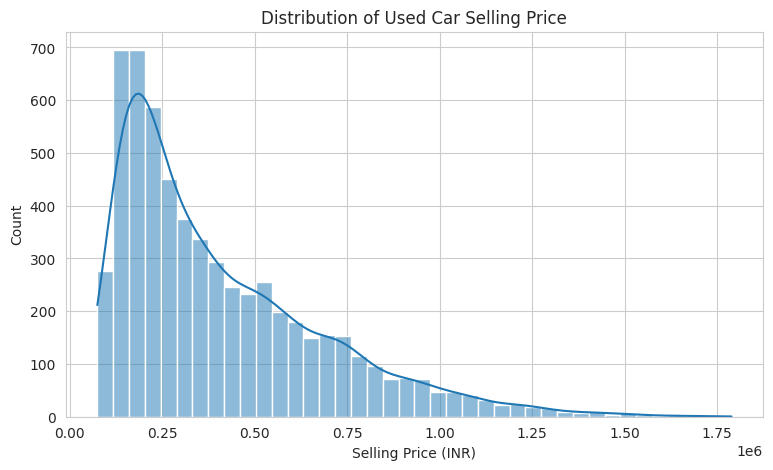

In [6]:
sns.histplot(df["selling_price"], bins=40, kde=True)
plt.title("Distribution of Used Car Selling Price")
plt.xlabel("Selling Price (INR)")
plt.show()

### 3.2 Price vs Car Age — Depreciation Effect
As expected, price drops sharply as car age increases — a classic depreciation curve.

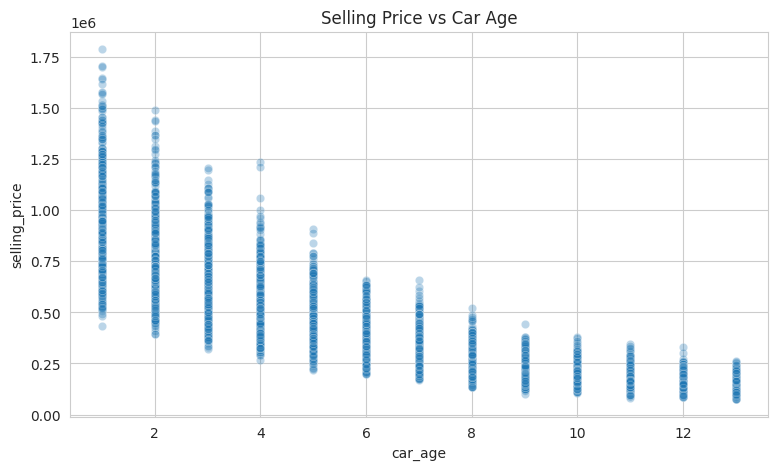

In [7]:
sns.scatterplot(data=df, x="car_age", y="selling_price", alpha=0.3)
plt.title("Selling Price vs Car Age")
plt.show()

### 3.3 Average Price by Brand

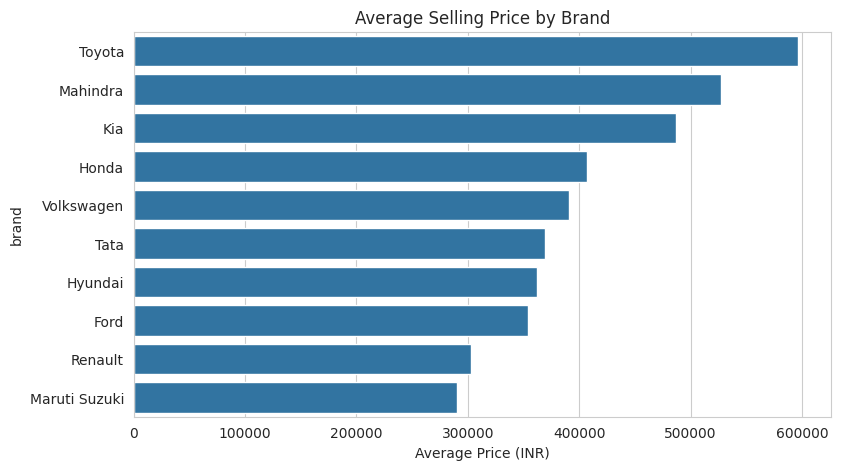

In [8]:
brand_avg = df.groupby("brand")["selling_price"].mean().sort_values(ascending=False)
sns.barplot(x=brand_avg.values, y=brand_avg.index)
plt.title("Average Selling Price by Brand")
plt.xlabel("Average Price (INR)")
plt.show()

### 3.4 Average Price by City
Metro cities like Mumbai and Bengaluru show higher resale value — consistent with real
demand patterns CARS24 sees across Tier-1 vs Tier-2 cities.

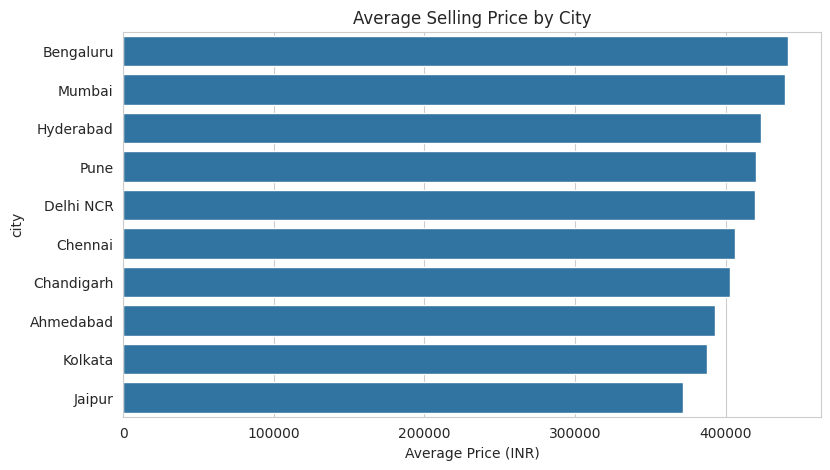

In [9]:
city_avg = df.groupby("city")["selling_price"].mean().sort_values(ascending=False)
sns.barplot(x=city_avg.values, y=city_avg.index)
plt.title("Average Selling Price by City")
plt.xlabel("Average Price (INR)")
plt.show()

### 3.5 Correlation Heatmap

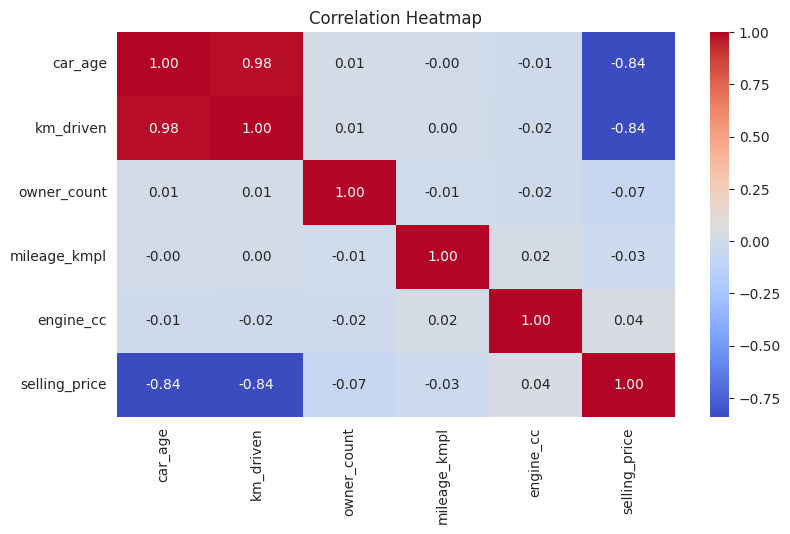

In [10]:
numeric_cols = ["car_age", "km_driven", "owner_count", "mileage_kmpl", "engine_cc", "selling_price"]
sns.heatmap(df[numeric_cols].corr(), annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Heatmap")
plt.show()

### 3.6 Price by Fuel Type & Transmission

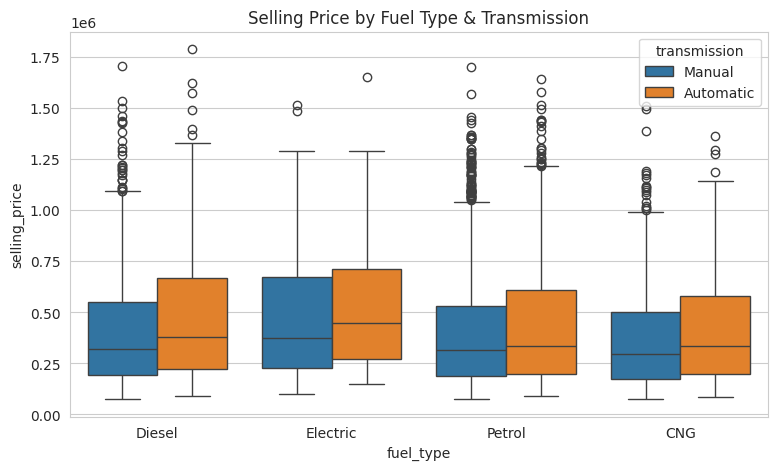

In [11]:
sns.boxplot(data=df, x="fuel_type", y="selling_price", hue="transmission")
plt.title("Selling Price by Fuel Type & Transmission")
plt.show()

## 4. Feature Engineering
- `km_per_year`: normalizes km driven by car age — helps the model distinguish a
  5-year-old car driven hard vs gently.
- One-hot encoding for categorical variables (brand, city, fuel_type, transmission, insurance).
- Standard scaling for numeric variables (helps Linear Regression converge better).

In [12]:
df["km_per_year"] = df["km_driven"] / df["car_age"].replace(0, 1)

feature_cols = ["brand", "city", "car_age", "km_driven", "fuel_type", "transmission",
                 "owner_count", "mileage_kmpl", "engine_cc", "insurance_valid", "km_per_year"]
target_col = "selling_price"

X = df[feature_cols]
y = df[target_col]

categorical_features = ["brand", "city", "fuel_type", "transmission", "insurance_valid"]
numeric_features = ["car_age", "km_driven", "owner_count", "mileage_kmpl", "engine_cc", "km_per_year"]

preprocessor = ColumnTransformer(transformers=[
    ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_features),
    ("num", StandardScaler(), numeric_features),
])

## 5. Train / Test Split

In [13]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print("Train:", X_train.shape, "Test:", X_test.shape)

Train: (4800, 11) Test: (1200, 11)


## 6. Train & Compare Models
We train three models of increasing complexity to see how much predictive power we gain:
- **Linear Regression** — simple baseline, assumes linear relationships
- **Random Forest** — captures non-linear relationships & feature interactions
- **XGBoost** — gradient boosting, typically state-of-the-art for tabular data

In [14]:
models = {
    "Linear Regression": LinearRegression(),
    "Random Forest": RandomForestRegressor(n_estimators=200, max_depth=12, random_state=42, n_jobs=-1),
    "XGBoost": XGBRegressor(n_estimators=300, max_depth=6, learning_rate=0.08, random_state=42, n_jobs=-1),
}

results = {}
pipelines = {}

for name, model in models.items():
    pipe = Pipeline([("preprocessor", preprocessor), ("model", model)])
    pipe.fit(X_train, y_train)
    preds = pipe.predict(X_test)

    rmse = np.sqrt(mean_squared_error(y_test, preds))
    mae = mean_absolute_error(y_test, preds)
    r2 = r2_score(y_test, preds)

    results[name] = {"RMSE": rmse, "MAE": mae, "R2": r2}
    pipelines[name] = pipe
    print(f"{name:20s} | RMSE: {rmse:,.0f} | MAE: {mae:,.0f} | R2: {r2:.4f}")

Linear Regression    | RMSE: 103,745 | MAE: 80,298 | R2: 0.8475


Random Forest        | RMSE: 61,283 | MAE: 40,113 | R2: 0.9468


XGBoost              | RMSE: 47,117 | MAE: 30,688 | R2: 0.9685


## 7. Model Comparison

In [15]:
results_df = pd.DataFrame(results).T
results_df

,RMSE,MAE,R2
Linear Regression,103744.560605,80298.051264,0.847481
Random Forest,61283.379880,40113.452934,0.946779
XGBoost,47117.397551,30688.386719,0.968540


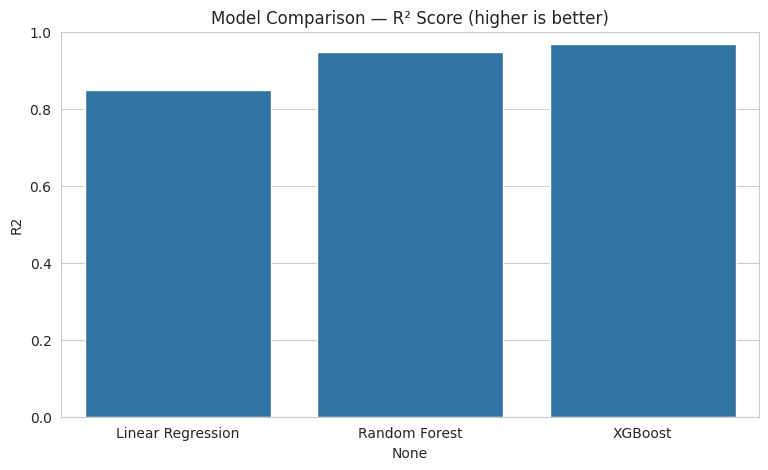

In [16]:
sns.barplot(x=results_df.index, y=results_df["R2"])
plt.title("Model Comparison — R² Score (higher is better)")
plt.ylim(0, 1)
plt.show()

**Observation:** XGBoost outperforms both Linear Regression and Random Forest,
confirming that the price relationship is non-linear and benefits from gradient
boosting's ability to model complex feature interactions (e.g. brand × age × city).

## 8. Feature Importance (Best Model)
Understanding *why* the model predicts a certain price is as important as the
prediction itself — this is what we'd present to the business team.

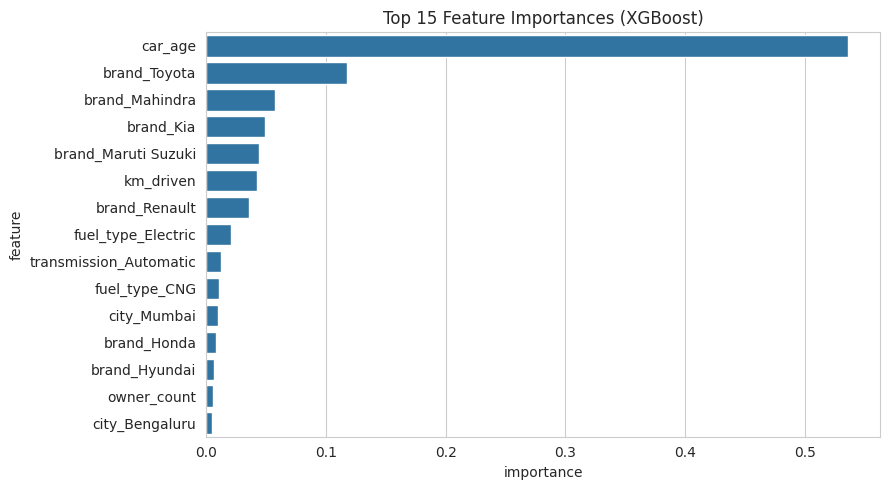

In [17]:
best_name = results_df["R2"].astype(float).idxmax()
best_pipe = pipelines[best_name]

ohe = best_pipe.named_steps["preprocessor"].named_transformers_["cat"]
cat_names = list(ohe.get_feature_names_out(categorical_features))
all_names = cat_names + numeric_features

importances = best_pipe.named_steps["model"].feature_importances_
fi = pd.DataFrame({"feature": all_names, "importance": importances}).sort_values("importance", ascending=False).head(15)

sns.barplot(data=fi, x="importance", y="feature")
plt.title(f"Top 15 Feature Importances ({best_name})")
plt.tight_layout()
plt.show()

## 9. Conclusion

- **Best model:** XGBoost, R² ≈ 0.97 on held-out test data.
- **Most influential factors:** car age, km driven, and brand — consistent with
  real-world used-car depreciation economics.
- **Business application:** This kind of model could power an instant-quote feature
  for sellers, help ops teams flag mispriced listings, and support inventory
  pricing strategy across cities.

**Next steps for a production version:**
- Train on real historical transaction data instead of synthetic data
- Add condition/damage assessment features (from inspection reports)
- Retrain periodically to capture market price shifts
- A/B test the pricing model's suggested price against actual sale outcomes